In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


# 1. Import Libraries
# 2. Load Dataset
# 3. Data Understanding
# 4. Data Cleaning
# 5. Exploratory Data Analysis
# 6. Text Preprocessing
# 7. Feature Engineering (TF-IDF)
# 8. Model Building
# 9. Hyperparameter Tuning
# 10. Model Comparison
# 11. Final Submission

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [3]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')
train.head()

,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


The dataset contains textual movie reviews and a categorical target variable representing sentiment.

In [5]:
train.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [6]:
train.isnull().sum()

id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

In [7]:
print(train.columns)

Index(['id', 'phrase', 'feature_1', 'feature_2', 'feature_3', 'sentiment'], dtype='object')


In [8]:
train['phrase'] = train['phrase'].fillna('')
test['phrase'] = test['phrase'].fillna('')

In [9]:
train.duplicated().sum()
train = train.drop_duplicates()

In [10]:
train['phrase_length'] = train['phrase'].apply(len)

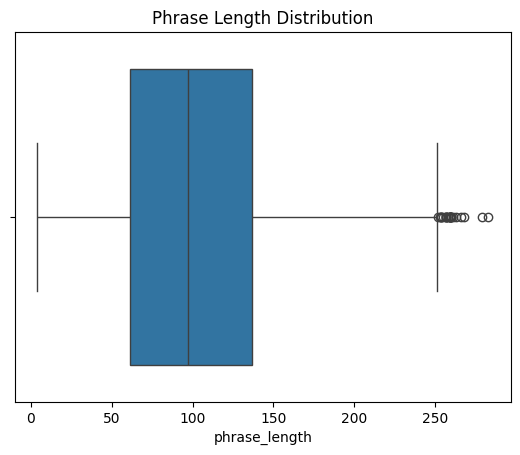

In [11]:
sns.boxplot(x=train['phrase_length'])
plt.title("Phrase Length Distribution")
plt.show()

Some outliers exist due to long reviews, but they are retained as they contain meaningful information.

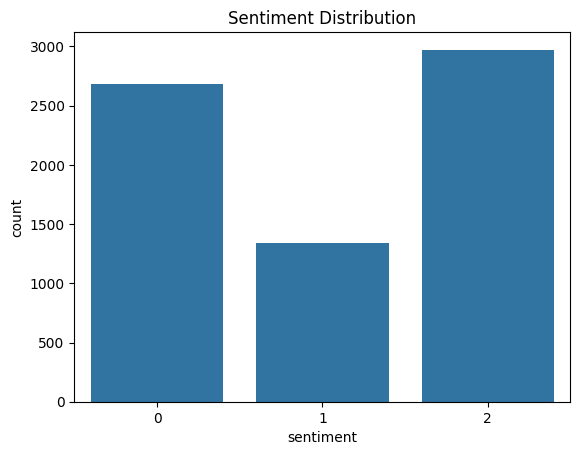

In [12]:
sns.countplot(x=train['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

Dataset is balanced between positive and negative sentiments.

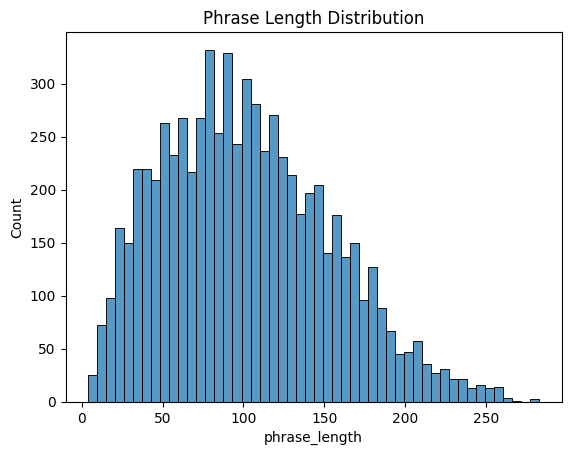

In [13]:
sns.histplot(train['phrase_length'], bins=50)
plt.title("Phrase Length Distribution")
plt.show()

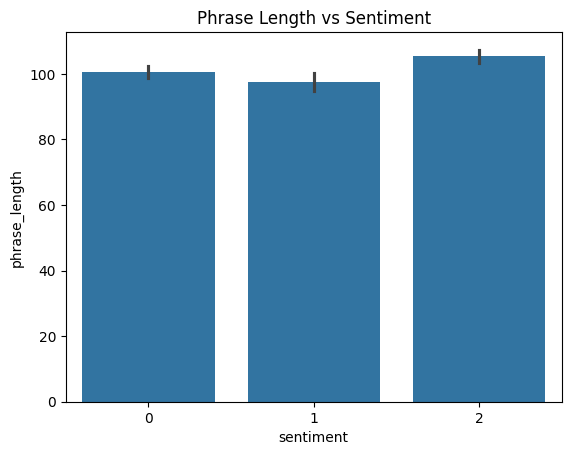

In [14]:
sns.barplot(x='sentiment', y='phrase_length', data=train)
plt.title("Phrase Length vs Sentiment")
plt.show()

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

train['phrase'] = train['phrase'].apply(clean_text)
test['phrase'] = test['phrase'].apply(clean_text)

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(train['phrase'])
test_X = vectorizer.transform(test['phrase'])

y = train['sentiment']

TF-IDF converts text into numerical vectors representing importance of words.

In [17]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
import scipy

# Fill missing values in numeric features
train[['feature_1','feature_2','feature_3']] = train[['feature_1','feature_2','feature_3']].fillna(0)
test[['feature_1','feature_2','feature_3']] = test[['feature_1','feature_2','feature_3']].fillna(0)

extra_features = train[['feature_1', 'feature_2', 'feature_3']].values
test_extra = test[['feature_1', 'feature_2', 'feature_3']].values

# Combine text + numeric
X = scipy.sparse.hstack((X, extra_features))
test_X = scipy.sparse.hstack((test_X, test_extra))

In [19]:
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "NaiveBayes": MultinomialNB(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "GradientBoost": GradientBoostingClassifier()
}

In [20]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    print(f"{name} Accuracy:", acc)

Logistic Accuracy: 0.615
NaiveBayes Accuracy: 0.6271428571428571
SVM Accuracy: 0.6285714285714286
RandomForest Accuracy: 0.5564285714285714
DecisionTree Accuracy: 0.4764285714285714
KNN Accuracy: 0.3464285714285714
GradientBoost Accuracy: 0.5135714285714286


In [21]:
pd.DataFrame(results, index=["Accuracy"]).T.sort_values(by="Accuracy", ascending=False)

,Accuracy
SVM,0.628571
NaiveBayes,0.627143
Logistic,0.615000
RandomForest,0.556429
GradientBoost,0.513571
DecisionTree,0.476429
KNN,0.346429


In [22]:
param_grid = {'C':[0.1,1,10]}

grid = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, cv=3)
grid.fit(X_train, y_train)

best_log = grid.best_estimator_

In [23]:
param_grid = {'C':[0.1,1]}

grid_svm = GridSearchCV(SVC(), param_grid, cv=3)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

In [24]:
param_grid = {'n_estimators':[100,200]}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid, cv=3)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

In [25]:
final_model = best_log
final_model.fit(X, y)

LogisticRegression(C=1, max_iter=2000)

In [26]:
preds = final_model.predict(test_X)

In [27]:
submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': preds
})

submission.to_csv('submission.csv', index=False)

In [28]:
import pandas as pd

submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': preds
})

submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")

Submission file created successfully!
